In [ ]:
import re
import pandas as pd

# Read the .log file
with open("pixie_data.log", "r") as f:
    lines = f.readlines()

# Keep only the lines that start with "Time="
data_lines = [line.strip() for line in lines if line.startswith("Time=")]

# Parse key=value pairs into dictionaries
records = []
for line in data_lines:
    pairs = re.findall(r'(\w+)=([-\d.]+)', line)
    record = {k: float(v) for k, v in pairs}
    records.append(record)

# Convert to DataFrame
df = pd.DataFrame(records)

# Save to CSV
df.to_csv("pixie_data.csv", index=False)

print("✅ Conversion complete! Saved as pixie_data.csv")
print(df.head())

✅ Conversion complete! Saved as pixie_data.csv
       Time   High  Pressure  TempIn  TempOut   GX   GY   GZ   AX   AY   AZ  \
0  346219.0 -58.78   1020.33   24.25    47.88  0.0  0.0  0.0  0.0  0.0  0.0   
1  349542.0 -58.86   1020.34   24.25    47.94  0.0  0.0  0.0  0.0  0.0  0.0   
2  352883.0 -59.19   1020.38   24.12    47.94  0.0  0.0  0.0  0.0  0.0  0.0   
3  356165.0 -59.03   1020.36   24.12    47.94  0.0  0.0  0.0  0.0  0.0  0.0   
4  359495.0 -55.80   1019.97   24.00    47.94  0.0  0.0  0.0  0.0  0.0  0.0   

     MX    MY    MZ   SD  TeTime  mpOut  empOut  TTime  
0 -0.20  0.43  0.34  1.0     NaN    NaN     NaN    NaN  
1 -0.19  0.43  0.35  1.0     NaN    NaN     NaN    NaN  
2 -0.18  0.43  0.36  1.0     NaN    NaN     NaN    NaN  
3 -0.21  0.43  0.34  1.0     NaN    NaN     NaN    NaN  
4 -0.25  0.41  0.35  1.0     NaN    NaN     NaN    NaN  


In [ ]:
print(max(df["TempIn"]), max(df["TempOut"]), max(df["Pressure"]))
print(min(df["TempIn"]), min(df["TempOut"]), min(df["Pressure"]))

24.37 49.13 1020.53
-57.38 -26.37 9.05


In [ ]:


# Load your CSV file
df = pd.read_csv("pixie_data.csv")

# Parse the start date from your log header
start_time = pd.to_datetime("2025-10-04 11:45:56")

# Convert milliseconds to a timedelta and add to start_time
df["DateTime"] = start_time + pd.to_timedelta(df["Time"], unit="ms")

# Optional: format for readability
df["DateTime_str"] = df["DateTime"].dt.strftime("%Y-%m-%d %H:%M:%S.%f").str[:-3]

# Save to CSV again with the new column
df.to_csv("pixie_data_with_time.csv", index=False)

print(df[["Time", "DateTime_str"]].head())



       Time             DateTime_str
0  346219.0  2025-10-04 11:51:42.219
1  349542.0  2025-10-04 11:51:45.542
2  352883.0  2025-10-04 11:51:48.883
3  356165.0  2025-10-04 11:51:52.165
4  359495.0  2025-10-04 11:51:55.495


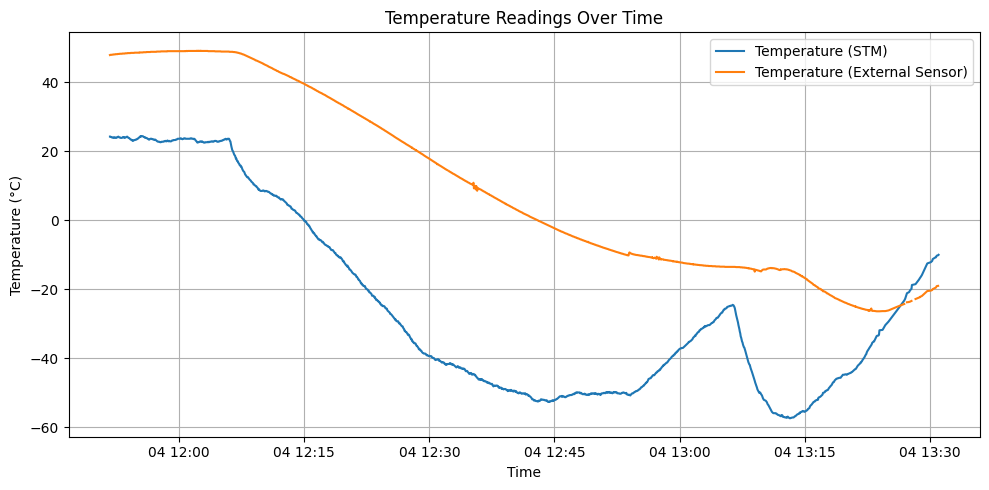

In [ ]:
import matplotlib.pyplot as plt

# Load the data (with DateTime column)
df = pd.read_csv("pixie_data_with_time.csv", parse_dates=["DateTime"])

# Plot both temperatures over time
plt.figure(figsize=(10, 5))
plt.plot(df["DateTime"], df["TempIn"], label="Temperature (STM)", linewidth=1.5)
plt.plot(df["DateTime"], df["TempOut"], label="Temperature (External Sensor)", linewidth=1.5)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Readings Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


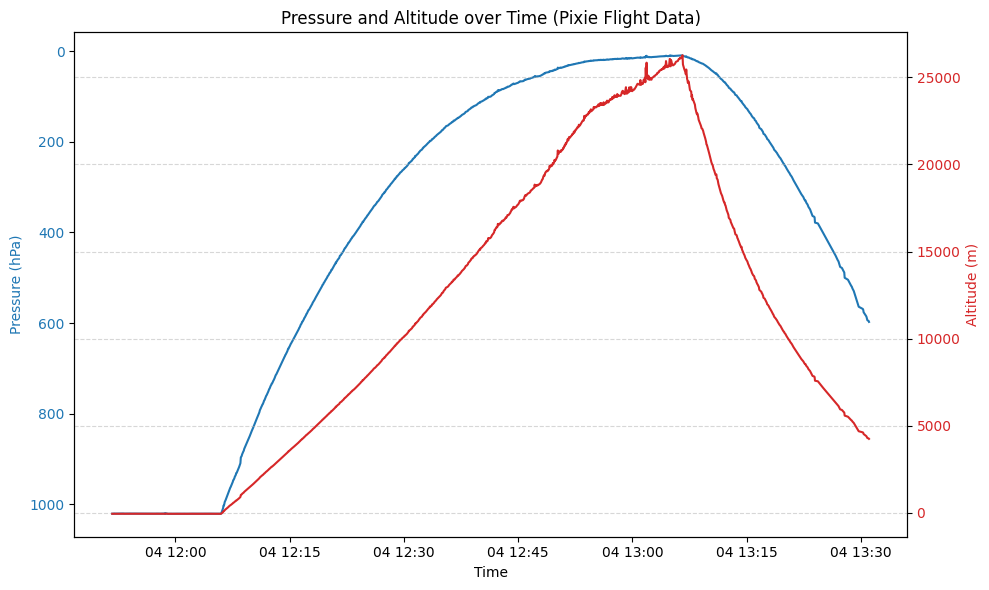

In [ ]:
import numpy as np

# --- Step 1: Load the CSV with timestamps ---
df = pd.read_csv("pixie_data_with_time.csv", parse_dates=["DateTime"])

# --- Step 2: Compute altitude from pressure ---
# Barometric formula:
# h = 44330 * (1 - (P / P0)**(1/5.255))
P0 = 1013.25  # hPa (sea-level standard pressure)
df["Altitude_m"] = 44330 * (1 - (df["Pressure"] / P0) ** (1/5.255))

# --- Step 3: Plot pressure and altitude over time ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# Pressure (left axis)
ax1.set_xlabel("Time")
ax1.set_ylabel("Pressure (hPa)", color="tab:blue")
ax1.plot(df["DateTime"], df["Pressure"], color="tab:blue", label="Pressure", lw=1.5)
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.invert_yaxis()  # Pressure decreases with altitude

# Altitude (right axis)
ax2 = ax1.twinx()
ax2.set_ylabel("Altitude (m)", color="tab:red")
ax2.plot(df["DateTime"], df["Altitude_m"], color="tab:red", label="Altitude", lw=1.5)
ax2.tick_params(axis='y', labelcolor="tab:red")

plt.title("Pressure and Altitude over Time (Pixie Flight Data)")
fig.tight_layout()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()


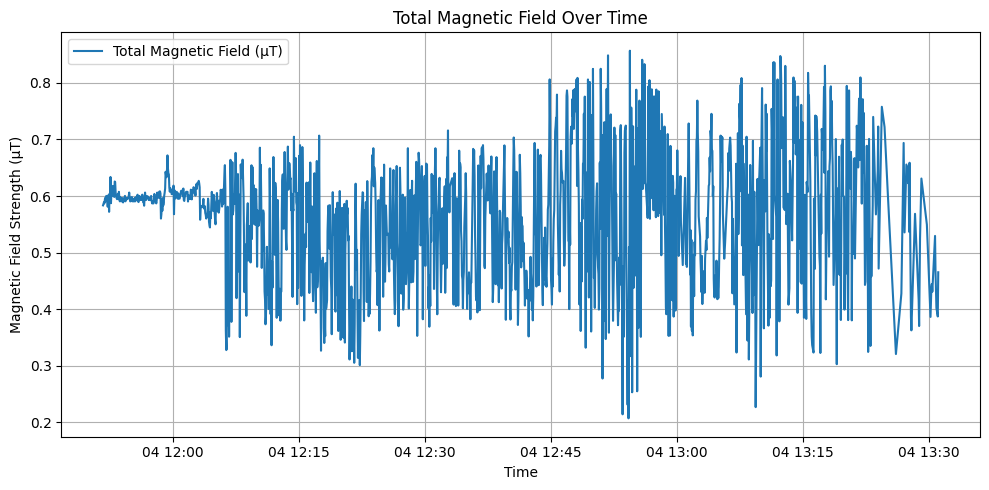

In [ ]:
df["Mag_Total"] = (df["MX"]**2 + df["MY"]**2 + df["MZ"]**2)**0.5
plt.figure(figsize=(10,5))
plt.plot(df["DateTime"], df["Mag_Total"], label="Total Magnetic Field (µT)")
plt.xlabel("Time")
plt.ylabel("Magnetic Field Strength (µT)")
plt.title("Total Magnetic Field Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2197021922.py:29: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  heading_rad = np.radians(df["Heading_deg"].fillna(method="ffill"))


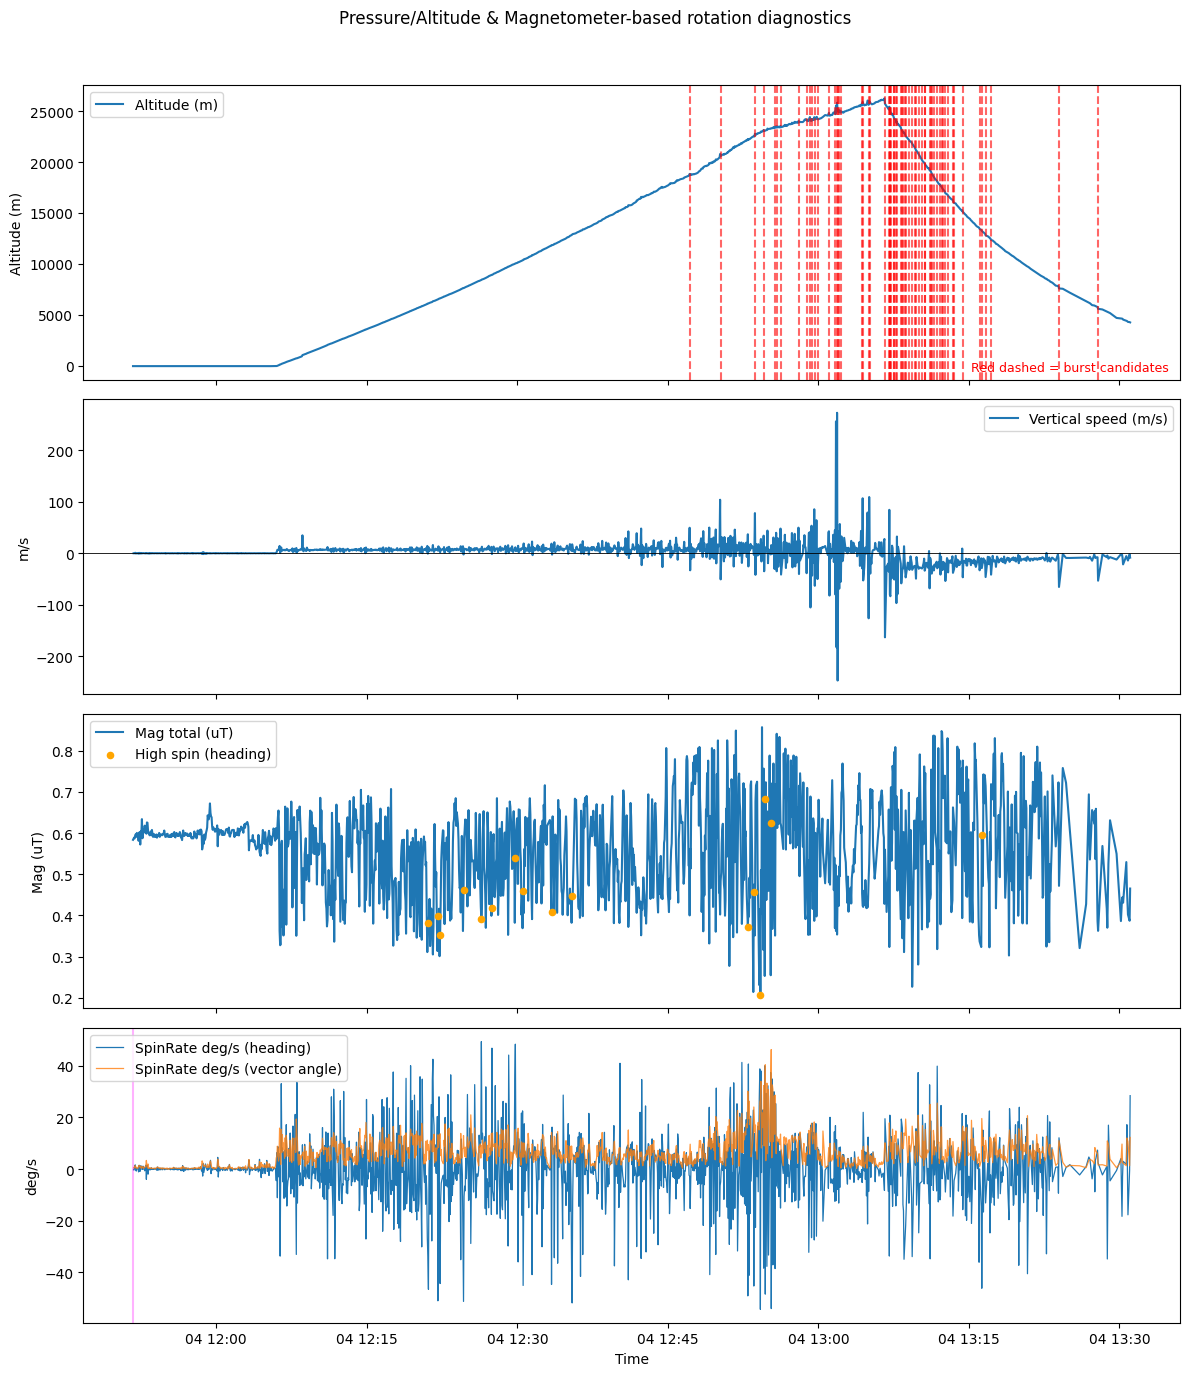

Burst candidate timestamps (top 5):
                    DateTime    Altitude_m  VertSpeed_m_s
969  2025-10-04 12:47:13.401  18732.975156     -33.180411
1024 2025-10-04 12:50:15.594  20635.313208     -50.838939
1082 2025-10-04 12:53:43.788  22650.300623     -41.990497
1096 2025-10-04 12:54:35.840  23051.811155     -35.057097
1114 2025-10-04 12:55:37.732  23355.950041     -30.585208

Top high spin moments (heading-based):
                    DateTime  SpinRate_deg_s_heading  SpinRate_deg_s_vec
615  2025-10-04 12:26:24.984               49.443242            8.966350
674  2025-10-04 12:29:48.129               48.425245           15.293780
633  2025-10-04 12:27:28.199               46.882473            7.080596
548  2025-10-04 12:22:18.388              -44.442828           13.654841
730  2025-10-04 12:33:24.467              -44.801282           14.190664
686  2025-10-04 12:30:34.668              -45.182417           10.156761
1079 2025-10-04 12:53:34.046              -45.407451           24

In [ ]:
# Motion_from_Mag_and_Pressure.py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Load data ---
df = pd.read_csv("pixie_data_with_time.csv", parse_dates=["DateTime"])
# ensure sorted
df = df.sort_values("DateTime").reset_index(drop=True)

# seconds since start for rate calculations
df["Time_s"] = (df["DateTime"] - df["DateTime"].iloc[0]).dt.total_seconds()

# --- Altitude from pressure (barometric formula) ---
P0 = 1013.25
df["Altitude_m"] = 44330 * (1 - (df["Pressure"] / P0) ** (1/5.255))

# vertical speed (m/s)
df["Alt_diff"] = df["Altitude_m"].diff()
df["dt"] = df["Time_s"].diff().replace(0, np.nan)
df["VertSpeed_m_s"] = df["Alt_diff"] / df["dt"]

# --- Magnetometer magnitude and heading ---
df["Mag_Total"] = np.sqrt(df["MX"]**2 + df["MY"]**2 + df["MZ"]**2)

# XY-plane heading (degrees)
df["Heading_deg"] = np.degrees(np.arctan2(df["MY"], df["MX"]))
# unwrap heading to avoid 360->0 jumps
heading_rad = np.radians(df["Heading_deg"].fillna(method="ffill"))
heading_unwrapped = np.unwrap(heading_rad)
df["Heading_unwrapped_deg"] = np.degrees(heading_unwrapped)

# spin rate from heading (deg/s)
df["Heading_diff_deg"] = df["Heading_unwrapped_deg"].diff()
df["SpinRate_deg_s_heading"] = df["Heading_diff_deg"] / df["dt"]

# alternative angular rate: angle between consecutive 3D magnetometer vectors
vec = df[["MX","MY","MZ"]].to_numpy()
# compute angle between v[i] and v[i-1] using dot product; guard against numerical errors
angles = np.zeros(len(vec))
for i in range(1, len(vec)):
    v1 = vec[i-1]
    v2 = vec[i]
    denom = np.linalg.norm(v1) * np.linalg.norm(v2)
    if denom == 0:
        angles[i] = 0.0
    else:
        cosang = np.clip(np.dot(v1, v2) / denom, -1.0, 1.0)
        angles[i] = np.degrees(np.arccos(cosang))
df["AngleBetweenVecs_deg"] = angles
df["SpinRate_deg_s_vec"] = df["AngleBetweenVecs_deg"] / df["dt"]

# --- Detect suspicious / event points ---
# 1) Burst candidate: large change in vertical speed or altitude drop
#    (burst ~ sharp large negative vertical speed)
vs_threshold = df["VertSpeed_m_s"].quantile(0.01) * 0.5  # extreme negative
burst_candidates = df[df["VertSpeed_m_s"] <= vs_threshold].index

# 2) High spin candidates (heading-based and vector-based)
spin_thresh = max(10, np.nanpercentile(np.abs(df["SpinRate_deg_s_heading"].dropna()), 99))  # deg/s
high_spin_idx = df.index[np.abs(df["SpinRate_deg_s_heading"].fillna(0)) > spin_thresh]

# 3) Frozen/repeated data detection (Time stall / repeated rows)
time_stall_idx = df.index[df["Time_s"].diff().fillna(0) == 0]

# --- Plots ---
plt.style.use("default")
fig, axs = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

# Altitude + vertical speed
axs[0].plot(df["DateTime"], df["Altitude_m"], label="Altitude (m)")
axs[0].set_ylabel("Altitude (m)")
axs[0].legend(loc="upper left")
for idx in burst_candidates:
    axs[0].axvline(df.loc[idx, "DateTime"], color="red", linestyle="--", alpha=0.6)
axs[0].text(0.99, 0.02, "Red dashed = burst candidates", ha="right", va="bottom",
            transform=axs[0].transAxes, fontsize=9, color="red")

axs[1].plot(df["DateTime"], df["VertSpeed_m_s"], label="Vertical speed (m/s)")
axs[1].set_ylabel("m/s")
axs[1].axhline(0, color="k", lw=0.6)
axs[1].legend()

# Magnetometer magnitude + spin markers
axs[2].plot(df["DateTime"], df["Mag_Total"], label="Mag total (uT)")
axs[2].set_ylabel("Mag (uT)")
axs[2].legend(loc="upper left")
# overlay spin events
axs[2].scatter(df.loc[high_spin_idx, "DateTime"], df.loc[high_spin_idx, "Mag_Total"],
               color="orange", s=20, label="High spin (heading)", zorder=4)
axs[2].legend()

# Spin rate (vector-based & heading-based)
axs[3].plot(df["DateTime"], df["SpinRate_deg_s_heading"], label="SpinRate deg/s (heading)", lw=0.9)
axs[3].plot(df["DateTime"], df["SpinRate_deg_s_vec"], label="SpinRate deg/s (vector angle)", lw=0.9, alpha=0.8)
axs[3].set_ylabel("deg/s")
axs[3].legend()
for idx in time_stall_idx:
    axs[3].axvline(df.loc[idx, "DateTime"], color="magenta", alpha=0.3)

plt.xlabel("Time")
plt.suptitle("Pressure/Altitude & Magnetometer-based rotation diagnostics")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

# --- Quick summary prints ---
print("Burst candidate timestamps (top 5):")
print(df.loc[burst_candidates, ["DateTime","Altitude_m","VertSpeed_m_s"]].head())

print("\nTop high spin moments (heading-based):")
print(df.loc[high_spin_idx, ["DateTime","SpinRate_deg_s_heading","SpinRate_deg_s_vec"]].nlargest(10, "SpinRate_deg_s_heading"))

# Save diagnostics
df.to_csv("pixie_with_mag_motion.csv", index=False)
print("\nSaved diagnostics to pixie_with_mag_motion.csv")
